# Trajectory Taxonomy: ScienceWorld Compact, ALFWorld, WebShop

**Goal:** understand *what kinds of trajectories exist* in the three downstream
environments the AOMT models are evaluated on — ScienceWorld Compact, ALFWorld, and WebShop.

**Data source:** the Hugging Face dataset
[`Joshyxwa/cp2107-textworld-trajectories`](https://huggingface.co/datasets/Joshyxwa/cp2107-textworld-trajectories),
with ScienceWorld now loaded from the compact snapshot at
`cp2107-textworld-trajectories/scienceworld-compact-v2/` and ALFWorld / WebShop
using their per-environment `train/validation/test.jsonl` under
`cp2107-textworld-trajectories/alfworld/` and `cp2107-textworld-trajectories/webshop/`.

This notebook builds a **portable trajectory taxonomy** (a shared schema + slice
framework that works across all three environments) and characterizes each along
those axes: goal families, objective types, trajectory length, interaction patterns,
observation density, and action vocabulary. Taxonomy definitions are imported from
`scripts/transform/taxonomy.py` so nothing drifts from the existing audit artifacts.

The notebook's machinery lives in the `scripts/` package:

- **Utils** (`utils/common.py`) — `ROOT` (repo root, from the package location) and
  `find_repo_root(start)` (walk-up fallback for odd working directories), plus io/hash helpers.
- **Transforms** (`transform/trajectory_analysis.py`) — pure, display-free, importable/testable:
  - *Loading* — `load_jsonl` / `canonical_record` / `load_env` map each environment's raw
    `blocks` (`Goal/Think/Action/Observation`) into one canonical record shape
    (`env, trajectory_id, split, goal, actions, observations, thinks, state_labels`). All
    three environments share the `blocks` schema.
  - *Enrichment* — `enrich()` turns a record into a taxonomy-labelled feature dict.
  - *Aggregation* — `build_features()` (records → feature DataFrame), `action_verb_counts()`,
    `objective_stats()`, and `summary_row()`. The notebook's own inline figures reuse these.
- **Taxonomy dispatch** (`transform/{taxonomy,env_taxonomy}.py`) — environment-aware
  goal-family / objective-type / action-verb classifiers. ScienceWorld, ALFWorld, and WebShop
  are all defined in `env_taxonomy.py`; `taxonomy.py` keeps shared helpers and compatibility
  wrappers. ALFWorld still uses its exact `state_labels.task_type`; WebShop has search→click rules.
- **Visualisation** (`scripts/viz/trajectory_viz.py`) — `profile_env(env, records)` is the thin
  orchestrator (`build_features` → `plot_env_panels` → `objective_stats`, no chart code of its own);
  `plot_env_panels(df, records, env)` holds the 4-panel figure (goal-family / objective / length /
  top verbs); `render()` prints a single trajectory. This is the only layer that imports matplotlib.

## 0. Setup

In [ ]:
# auto-reload edited scripts/**/*.py without restarting the kernel
%load_ext autoreload
%autoreload 2

import sys, os, json, shutil, re
from pathlib import Path
from collections import Counter, defaultdict

# Import the local scripts package even when Jupyter starts in notebooks/.
REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                 if (p / "scripts" / "__init__.py").is_file())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.utils.common import ROOT, find_repo_root
from scripts.transform import taxonomy as ad
from scripts.viz import plot_theme as pt

'''
Transforms (loading / enrichment / aggregation) live in scripts/transform/trajectory_analysis.py;
the visualisation layer lives in scripts/viz/trajectory_viz.py. The split keeps the data
transforms importable and testable without a display, and lets this notebook's own inline figures
reuse the same feature tables. Both build on scripts/transform/{taxonomy,env_taxonomy}.py.

In the viz layer, profile_env is the thin orchestrator (build_features -> plot_env_panels ->
objective_stats) and plot_env_panels holds the chart logic — so profile_env carries no drawing
code of its own and the panels can be restyled without touching it.
'''
from scripts.transform import trajectory_analysis as ta
from scripts.viz import trajectory_viz as tv
from scripts.transform.trajectory_analysis import (
    load_jsonl, canonical_record, load_env, enrich, build_features, summary_row,
)
from scripts.viz.trajectory_viz import profile_env, render
from scripts.transform.env_taxonomy import action_verb   # used directly in the WebShop funnel cell below

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

pt.apply_theme()

# taxonomy classifiers live in scripts/transform/taxonomy.py; reused here so the notebook
# labels match artifacts/trajectory_features.csv exactly. ROOT is authoritative from the
# package (derived from its own location), and find_repo_root now lives in scripts/utils/common.py.
ARTIFACTS, SCRIPTS = ROOT / "artifacts", ROOT / "scripts"
TEXTWORLD_ROOT = ROOT / "cp2107-textworld-trajectories"
SCIENCEWORLD_DATA = TEXTWORLD_ROOT / "scienceworld-compact-v2"
ALFWORLD_DATA = TEXTWORLD_ROOT / "alfworld-success-v2"
WEBSHOP_DATA = TEXTWORLD_ROOT / "webshop"
ENV_DATA_DIRS = {
    "scienceworld": SCIENCEWORLD_DATA,
    "alfworld": ALFWORLD_DATA,
    "webshop": WEBSHOP_DATA,
}
print("repo root:", ROOT)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
repo root: C:\code\AOMT


## 1. Load all environments + coverage

In [3]:
ENVS = ("scienceworld", "alfworld", "webshop")
loaded, coverage = {}, []
for env in ENVS:
    data_dir = ENV_DATA_DIRS[env]
    records, is_present = load_env(env, data_dir)
    split_counts = Counter(record["split"] for record in records)
    loaded[env] = records
    coverage.append({
        "env": env,
        "present": is_present,
        "source": data_dir.relative_to(ROOT).as_posix(),
        "n_traj": len(records),
        **{
            split: split_counts.get(split, 0)
            for split in ("train", "validation", "test")
        },
    })

coverage_df = pd.DataFrame(coverage).set_index("env")
present_envs = coverage_df.index[coverage_df["present"]].tolist()
missing_envs = coverage_df.index[~coverage_df["present"]].tolist()
print(f"present: {present_envs} | missing: {missing_envs if missing_envs else 'none'}")

coverage_df

present: ['scienceworld', 'alfworld', 'webshop'] | missing: none


,present,source,n_traj,train,validation,test
env,,,,,,
scienceworld,True,cp2107-textworld-trajectories/scienceworld-com...,7095,3534,1762,1799
alfworld,True,cp2107-textworld-trajectories/alfworld-success-v2,3430,3208,111,111
webshop,True,cp2107-textworld-trajectories/webshop,3768,3014,377,377


## 2. ScienceWorld Compact

Baseline environment: the compact ScienceWorld snapshot used for the updated audit run. It still covers interactive science tasks (conductivity, find-a-thing, temperature/melting-point measurement, lifespan comparison, plant growth), and the updated compact snapshot also adds several comparison-heavy families (genetics trait dominance, inclined-plane friction, inclined-plane angle, electric-device power). The notebook now sources it from `scienceworld-compact-v2/`.

[scienceworld]  7095 trajectories | schemas: {'blocks': 7095}


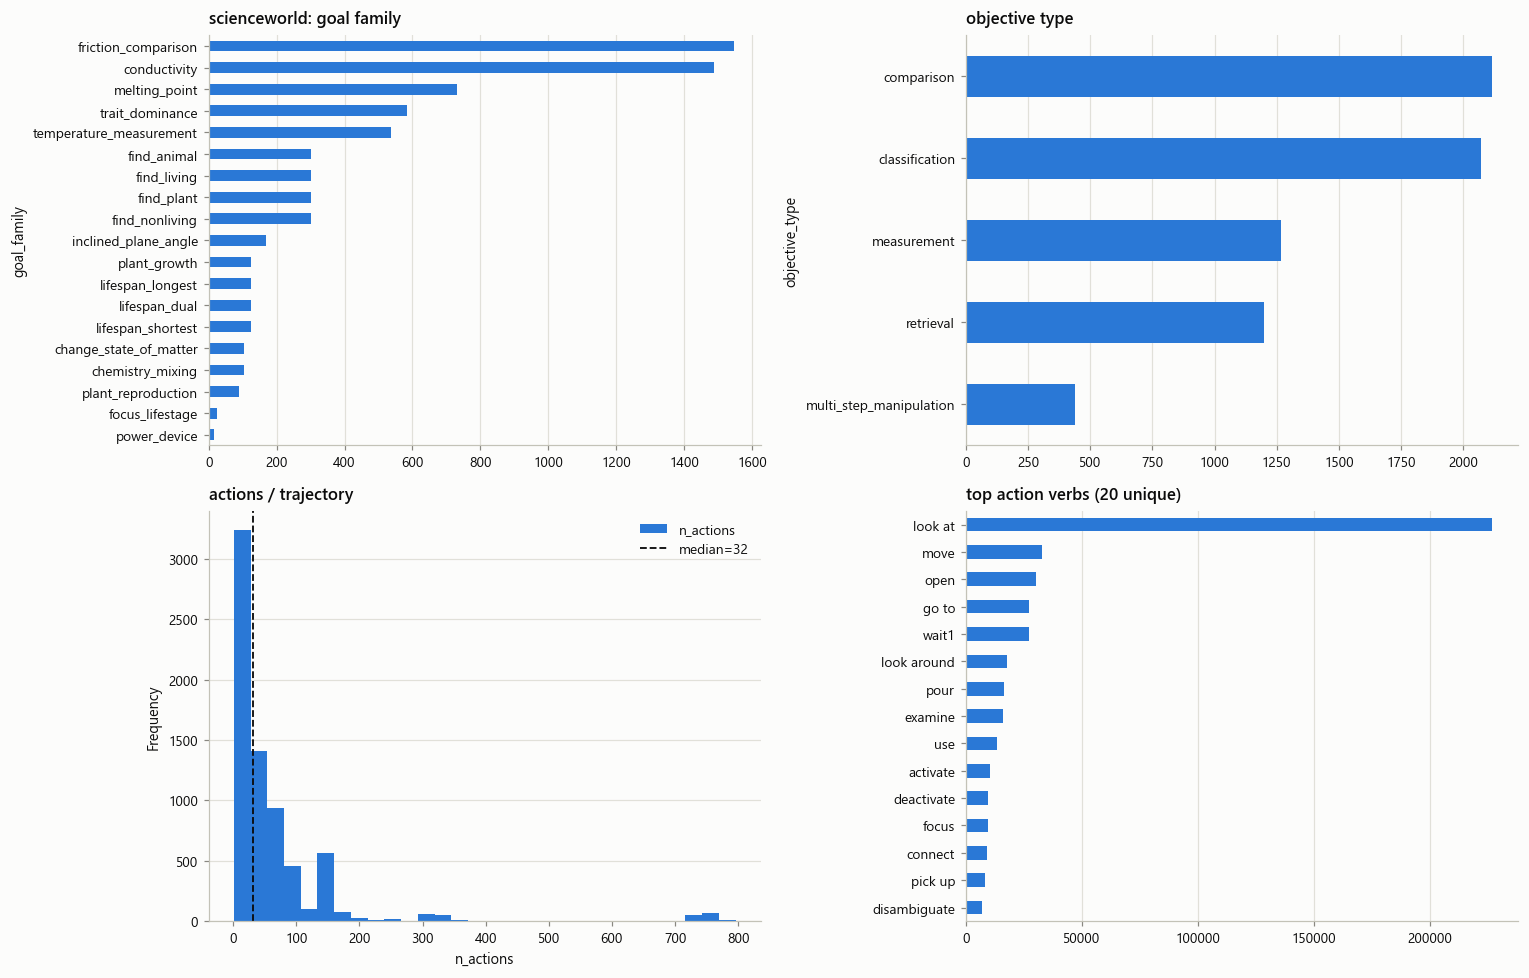

,count,median,mean,max
objective_type,,,,
classification,2073,36.0,63.2,264
comparison,2115,67.0,120.4,796
measurement,1268,23.0,35.2,95
multi_step_manipulation,439,38.0,47.1,166
retrieval,1200,12.0,11.0,16


,env,trajectory_id,split,goal,actions,observations,thinks,n_actions,n_observations,state_labels,_schema,goal_family,objective_type,source_format,goal_template_key,length_bin,interaction_pattern,ambiguity_pattern,avg_obs_chars,repeated_action_ratio
0,scienceworld,gold:boil:variation:10,train,Your task is to boil chocolate. For compounds ...,"[open door to hallway, go to hallway, open doo...","[This room is called the art studio. In it, yo...",[],40,41,{'look': 'This room is called the kitchen. In ...,blocks,change_state_of_matter,multi_step_manipulation,None,your task is to boil chocolate<num> for compou...,long,directed,none,84.780488,0.0
1,scienceworld,gold:boil:variation:11,train,Your task is to boil chocolate. For compounds ...,"[look around, pick up thermometer, open cupboa...","[This room is called the kitchen. In it, you s...",[],24,25,{'look': 'This room is called the foundry. In ...,blocks,change_state_of_matter,multi_step_manipulation,None,your task is to boil chocolate<num> for compou...,long,directed,none,140.560000,0.0
2,scienceworld,gold:boil:variation:12,train,Your task is to boil marshmallow. For compound...,"[open door to hallway, go to hallway, open doo...","[This room is called the living room. In it, y...",[],87,88,{'look': 'This room is called the foundry. In ...,blocks,change_state_of_matter,multi_step_manipulation,None,your task is to boil marshmallow<num> for comp...,long,directed,none,60.352273,0.0


In [ ]:
sw = profile_env("scienceworld", loaded["scienceworld"])
sw.head(3)

In [11]:
if sw is not None:
    by_id = {r["trajectory_id"]: r for r in loaded["scienceworld"]}
    for fam in ["conductivity", "find_animal", "plant_growth"]:
        sub = sw[sw["goal_family"] == fam]
        if len(sub): render(by_id[sub.iloc[0]["trajectory_id"]])

[scienceworld] id=gold:test-conductivity:variation:0  split=train  schema=blocks
GOAL: Your task is to determine if aluminum foil is electrically conductive. The aluminum foil is located around the workshop. First, focus on the aluminum foil. If it is electrically conductive, place it in the red box. If it is electrically nonconductive, place it in the green box.
------------------------------------------------------------------------------------------
  ACTION: open door to bedroom
  OBS   : This room is called the hallway. In it, you see:  	the agent 	a substance called air 	a picture You also see: 	A door to the art studio (that is close
  ACTION: go to bedroom
  OBS   : The door is now open.
  ACTION: open door to hallway
  OBS   : You move to the bedroom.
  ACTION: go to hallway
  OBS   : The door is already open.
  ACTION: open door to workshop
  OBS   : You move to the hallway.
  ACTION: go to workshop
  OBS   : The door is now open.
  ACTION: pick up aluminum foil
  OBS   : You

### 2.1 Interaction, ambiguity & observation density (ScienceWorld Compact-specific)

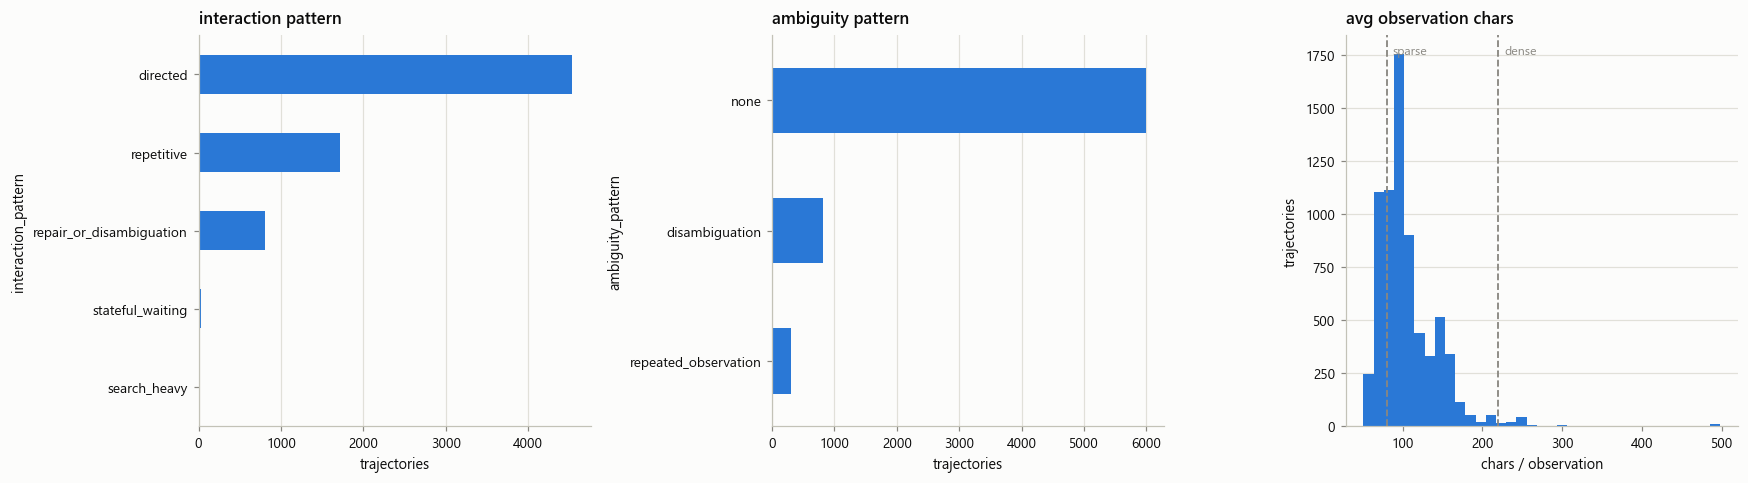

objective_type,classification,comparison,measurement,multi_step_manipulation,retrieval,All
goal_family,,,,,,
change_state_of_matter,0,0,0,104,0,104
chemistry_mixing,0,0,0,104,0,104
conductivity,1489,0,0,0,0,1489
find_animal,0,0,0,0,300,300
find_living,0,0,0,0,300,300
find_nonliving,0,0,0,0,300,300
find_plant,0,0,0,0,300,300
focus_lifestage,0,24,0,0,0,24
friction_comparison,0,1548,0,0,0,1548


In [10]:
if sw is not None:
    C = pt.env_color("scienceworld")          # this whole section is ScienceWorld -> one hue
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

    sw["interaction_pattern"].value_counts().plot.barh(ax=ax[0], color=C)
    ax[0].set_title("interaction pattern"); ax[0].set_xlabel("trajectories")
    ax[0].invert_yaxis(); pt.style_axes(ax[0], xgrid=True)

    sw["ambiguity_pattern"].value_counts().plot.barh(ax=ax[1], color=C)
    ax[1].set_title("ambiguity pattern"); ax[1].set_xlabel("trajectories")
    ax[1].invert_yaxis(); pt.style_axes(ax[1], xgrid=True)

    sw["avg_obs_chars"].plot.hist(bins=35, ax=ax[2], color=C)
    ax[2].set_title("avg observation chars"); ax[2].set_xlabel("chars / observation")
    ax[2].set_ylabel("trajectories"); pt.style_axes(ax[2])
    for x, name in [(80, "sparse"), (220, "dense")]:   # density-bin thresholds
        ax[2].axvline(x, color=pt.INK_MUTED, ls="--", lw=1.2)
        ax[2].annotate(name, xy=(x, 1), xycoords=("data", "axes fraction"),
                       xytext=(4, -12), textcoords="offset points",
                       color=pt.INK_MUTED, fontsize=8)

    plt.tight_layout(); plt.show()
    display(pd.crosstab(sw["goal_family"], sw["objective_type"], margins=True))

## 3. ALFWorld

Embodied household task completion (TextWorld + ALFRED). The **goal family is the
exact `state_labels.task_type`** (7 canonical ALFRED task types) rather than a
keyword guess. Actions are PDDL-style operators (`GotoLocation`, `PickupObject`,
`PutObject`, `ToggleObject`, `SliceObject`, `NoOp`). These are **offline plan traces**
— Think + Action dominate; the environment observation is essentially the initial
scene (≈1 observation per trajectory), so observation-density analysis doesn't apply
here the way it does for ScienceWorld.

[alfworld]  3430 trajectories | schemas: {'blocks': 3430}


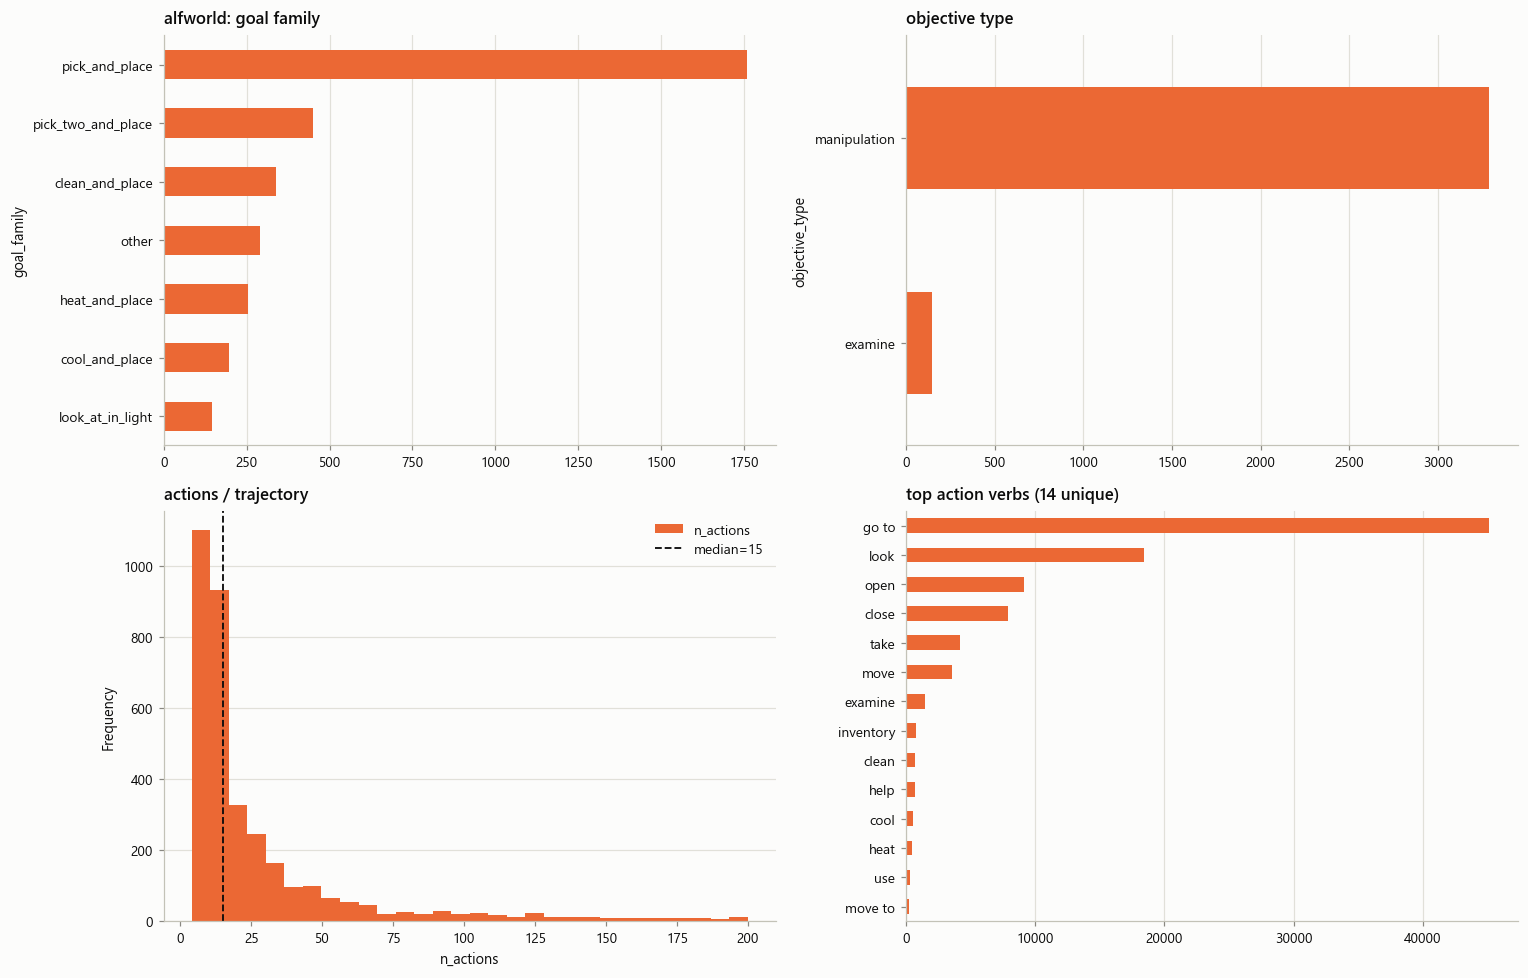

,count,median,mean,max
objective_type,,,,
examine,144,8.0,14.2,115
manipulation,3286,15.0,27.8,200


task_type source: state_labels (exact ALFRED labels)


,count,median,max
goal_family,,,
pick_and_place,1758,13.0,200
pick_two_and_place,450,66.0,200
clean_and_place,337,15.0,100
other,291,11.0,199
heat_and_place,254,16.0,104
cool_and_place,196,15.0,87
look_at_in_light,144,8.0,115


PDDL action operators: {'go': 45124, 'look': 18441, 'open': 9138, 'close': 7904, 'take': 4165, 'move': 3798, 'examine': 1478, 'inventory': 751, 'clean': 689, 'help': 687, 'cool': 552, 'heat': 480, 'use': 342}
share of precondition-stateful (clean/cool/heat) tasks: 0.0%
[alfworld] id=alfworld-630d802202c02720b891  split=train  schema=blocks
GOAL: Put a clean head of lettuce on a plate in the fridge.
------------------------------------------------------------------------------------------
  ACTION: look
  OBS   : -= Welcome to TextWorld, ALFRED! =-  You are in the middle of a room. Looking quickly around you, you see a cabinet 21, a cabinet 20, a cabinet 19, a 
  ACTION: go to sinkbasin 1
  OBS   : You are in the middle of a room. Looking quickly around you, you see nothing.
  ACTION: go to garbagecan 1
  OBS   : You arrive at sinkbasin 1. On the sinkbasin 1, you see a mug 2, and a spatula 3.
  ACTION: go to fridge 1
  OBS   : You arrive at garbagecan 1. On the garbagecan 1, you see not

In [13]:
af = profile_env("alfworld", loaded["alfworld"])
if af is not None:
    print("task_type source: state_labels (exact ALFRED labels)")
    display(af.groupby("goal_family")["n_actions"].agg(["count", "median", "max"]).sort_values("count", ascending=False))
    # PDDL-style action operator vocabulary
    ops = Counter(a.split(" ")[0] for r in loaded["alfworld"] for a in r["actions"])
    print("PDDL action operators:", dict(ops.most_common()))
    # precondition-stateful families (must clean/cool/heat before placing)
    stateful = af["goal_family"].isin(["pick_clean_then_place_in_recep",
        "pick_cool_then_place_in_recep", "pick_heat_then_place_in_recep"]).mean()
    print(f"share of precondition-stateful (clean/cool/heat) tasks: {stateful:.1%}")
    by_id = {r["trajectory_id"]: r for r in loaded["alfworld"]}
    render(by_id[af.iloc[0]["trajectory_id"]])

## 4. WebShop

Web navigation for online shopping: a natural-language product instruction, then a
`search[...]` / `click[...]` funnel over results → product → options → Buy Now.

The corpus is a **mix of two `source_formats`**: `goal_query_map` rows are single
`search[...]` query logs (median 1 action), while the unlabeled rows are **full
click-through trajectories** (up to ~113 actions). We surface that split explicitly
because it dominates the length distribution.

[webshop]  3768 trajectories | schemas: {'blocks': 3768}


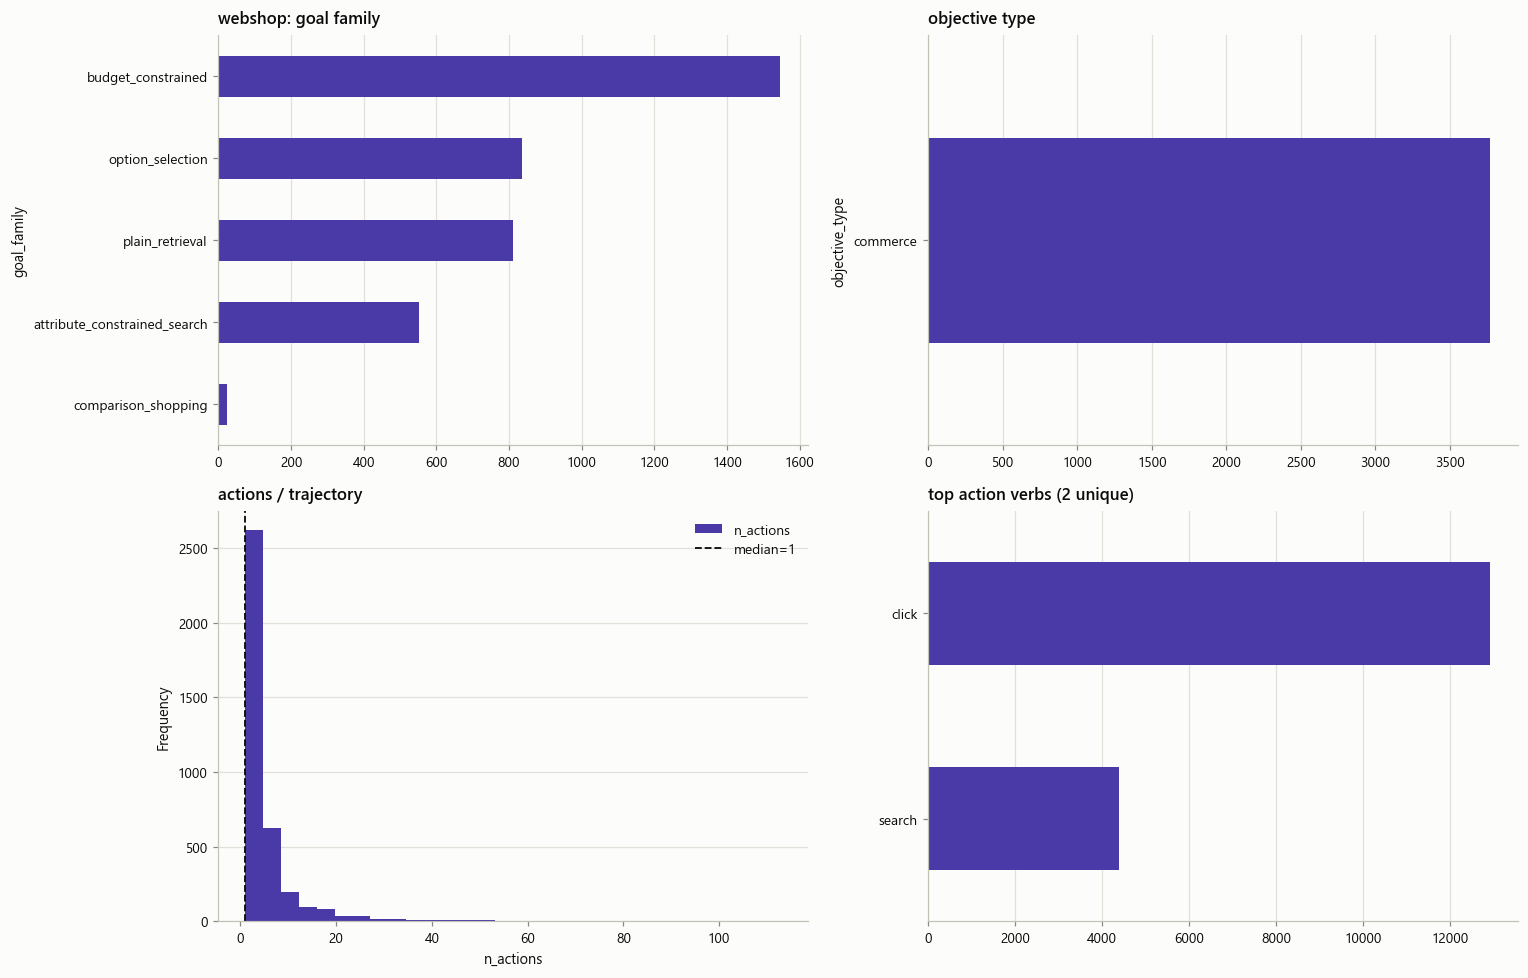

,count,median,mean,max
objective_type,,,,
commerce,3768,1.0,4.6,113


source formats: {'goal_query_map': np.int64(2197), 'full_click_log': np.int64(1571)}


,count,median,mean,max
fmt,,,,
full_click_log,1571,6.0,9.6,113
goal_query_map,2197,1.0,1.0,1


action funnel: {'search': 4394, 'click': 12914}
goal-family mix: {'budget_constrained': np.int64(1546), 'option_selection': np.int64(836), 'plain_retrieval': np.int64(811), 'attribute_constrained_search': np.int64(552), 'comparison_shopping': np.int64(23)}
[webshop] id=webshop-fdb16b008797  split=train  schema=blocks
GOAL: i need a high speed usb flash drive that is 32 gb, and price lower than 50.00 dollars
------------------------------------------------------------------------------------------
  ACTION: search[32 gb high speed usb flash drive ]
  OBS   : Amazon Shopping Game Instruction:   [button] Search [button_]
  ACTION: click[b085x5548b]
  OBS   : Instruction:  [button] Back to Search [button_] Page 1 (Total results: 50) [button] Next > [button_] [button] B0845XPB49 [button_] SanDisk 32GB Ultra 
  ACTION: click[features]
  OBS   : Instruction:  [button] Back to Search [button_] [button] < Prev [button_] V7 32GB USB 3.1 Flash Drive - 32 GB - USB 3.1-120 MB/s Read Speed - Black P

In [14]:
ws = profile_env("webshop", loaded["webshop"])
if ws is not None:
    ws2 = ws.assign(fmt=ws["source_format"].fillna("full_click_log"))
    print("source formats:", dict(ws2["fmt"].value_counts()))
    display(ws2.groupby("fmt")["n_actions"].agg(["count", "median", "mean", "max"]).round(1))
    funnel = Counter(action_verb(a, "webshop") for r in loaded["webshop"] for a in r["actions"])
    print("action funnel:", dict(funnel))
    print("goal-family mix:", dict(ws["goal_family"].value_counts()))
    by_id = {r["trajectory_id"]: r for r in loaded["webshop"]}
    full = ws[ws["n_actions"] > 3]                      # show a real click-through, not a 1-shot query
    ex = full.iloc[0] if len(full) else ws.iloc[0]
    render(by_id[ex["trajectory_id"]])

## 5. Cross-environment taxonomy summary

In [18]:
summary = pd.DataFrame([summary_row("scienceworld", sw, loaded["scienceworld"]),
                        summary_row("alfworld", af, loaded["alfworld"]),
                        summary_row("webshop", ws, loaded["webshop"])]) \
            .set_index("env")
summary

,status,n_traj,goal_families,objective_types,median_actions,dominant_interaction,top_verb
env,,,,,,,
scienceworld,empirical,7095,19,"classification, comparison, measurement, multi...",32,directed,look at
alfworld,empirical,3430,7,"examine, manipulation",15,directed,go to
webshop,empirical,3768,5,commerce,1,directed,click


In [19]:
from scripts.transform import granular_metrics as gm
gm_df = pd.DataFrame(gm.trajectory_metrics(r) for env in ENVS for r in loaded[env])
print(f'per-trajectory metrics: {len(gm_df)} rows x {gm_df.shape[1]} features')

key = ['goal_words','n_blocks','n_actions','n_observations','n_thinks',
       'avg_action_words','avg_obs_words','avg_think_words','traj_words',
       'repeated_actions_total','nav_ratio','manip_ratio','think_ratio']
display(gm_df.groupby('env')[key].mean().round(1).T)
display(gm_df.groupby('env')['traj_words'].describe(percentiles=[.1,.5,.9])[['count','10%','50%','90%','max']].round(0))

per-trajectory metrics: 14293 rows x 32 features


env,alfworld,scienceworld,webshop
goal_words,8.7,41.1,16.9
n_blocks,56.5,132.9,10.2
n_actions,27.3,65.4,4.6
n_observations,28.3,66.4,4.6
n_thinks,0.0,0.0,0.0
avg_action_words,3.8,5.0,4.8
avg_obs_words,20.7,19.7,60.5
avg_think_words,0.0,0.0,0.0
traj_words,609.7,1676.3,639.7
repeated_actions_total,10.8,48.3,1.1


,count,10%,50%,90%,max
env,,,,,
alfworld,3430.0,197.0,411.0,1256.0,4633.0
scienceworld,7095.0,270.0,752.0,4630.0,19122.0
webshop,3768.0,19.0,31.0,1654.0,18391.0


IndexingError: Too many indexers

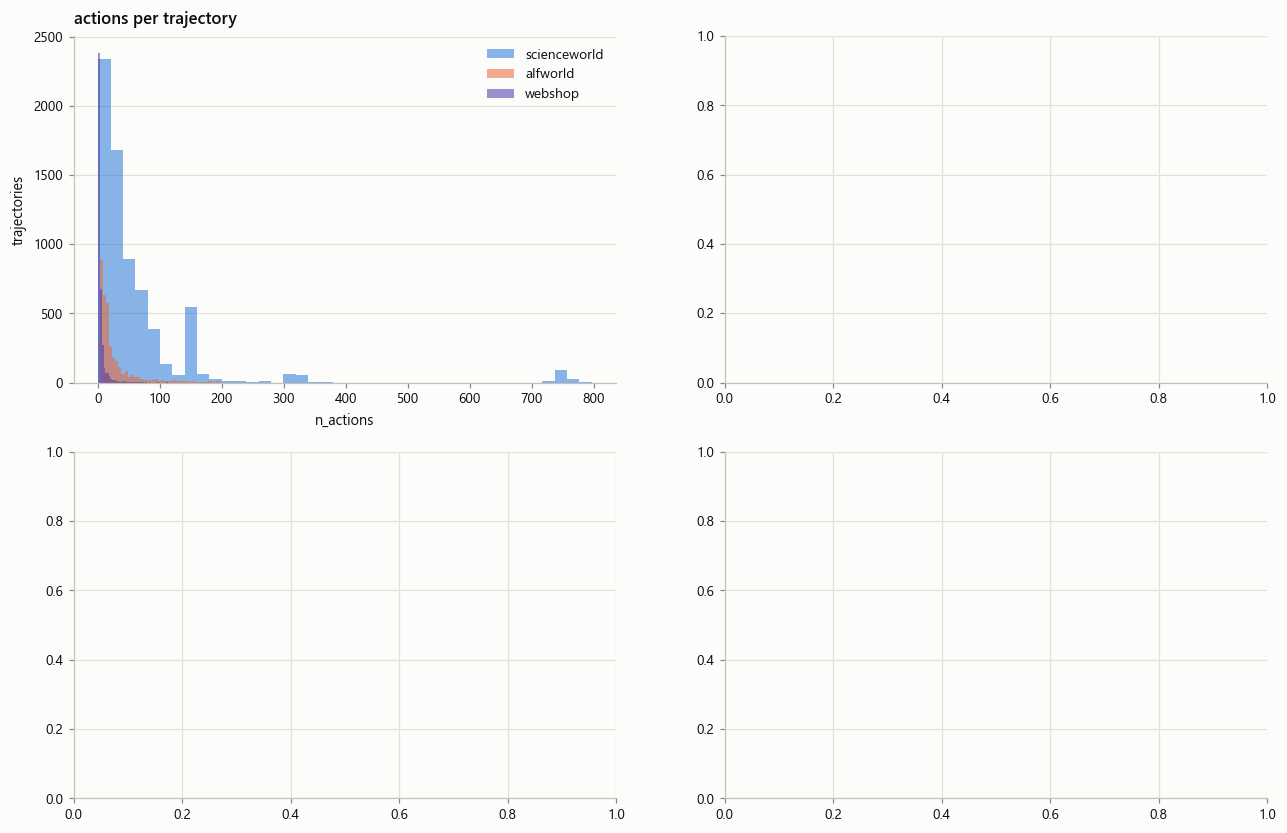

In [22]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

# --- actions per trajectory: three series, coloured by environment
for env in ENVS:
    gm_df[gm_df.env == env]["n_actions"].plot.hist(bins=40, alpha=0.55, ax=ax[0, 0], label=env, color=pt.env_color(env))
ax[0, 0].set_title("actions per trajectory")
ax[0, 0].set_xlabel("n_actions"); ax[0, 0].set_ylabel("trajectories")
ax[0, 0].legend(); pt.style_axes(ax[0, 0])

# --- block composition: think / action / observation share of every block
gm_df["block_total"] = gm_df["n_thinks"] + gm_df["n_actions"] + gm_df["n_observations"]
gm_df["think_ratio"] = gm_df["n_thinks"] / gm_df["block_total"].clip(lower=1)
gm_df["action_ratio"] = gm_df["n_actions"] / gm_df["block_total"].clip(lower=1)
gm_df["obs_ratio"] = gm_df["n_observations"] / gm_df["block_total"].clip(lower=1)

comp = gm_df.groupby("env")[["think_ratio", "action_ratio", "obs_ratio"]].mean().loc[ENVS]
comp.plot.barh(stacked=True, ax=ax[0, 1], width=0.6, legend=False,
               color=[pt.BLOCK_COLORS[k] for k in ("think", "action", "observation")])
ax[0, 1].set_title("block composition (mean ratio)")
ax[0, 1].set_xlim(0, 1); ax[0, 1].set_xlabel("proportion of blocks"); ax[0, 1].set_ylabel("")
ax[0, 1].legend(["think", "action", "observation"], loc="lower right", ncols=3)
ax[0, 1].invert_yaxis()          # same env order as ENVS / the legend, top-to-bottom
pt.separate_segments(ax[0, 1]); pt.label_stacked(ax[0, 1]); pt.style_axes(ax[0, 1], xgrid=True)

# --- action-type mix
mix = gm_df.groupby("env")[["n_navigation", "n_manipulation", "n_other_actions"]].sum().loc[ENVS]
mix = mix.div(mix.sum(axis=1), axis=0)
mix.plot.barh(stacked=True, ax=ax[1, 0], width=0.6, legend=False,
              color=[pt.MIX_COLORS[k] for k in ("navigation", "manipulation", "other")])
ax[1, 0].set_title("action-type mix (share)")
ax[1, 0].set_xlim(0, 1); ax[1, 0].set_xlabel("share of actions"); ax[1, 0].set_ylabel("")
ax[1, 0].legend(["navigation", "manipulation", "other"], loc="lower right", ncols=3)
ax[1, 0].invert_yaxis()
pt.separate_segments(ax[1, 0]); pt.label_stacked(ax[1, 0]); pt.style_axes(ax[1, 0], xgrid=True)

# --- reasoning density: one bar per environment, so colour by environment
tpa = (gm_df.assign(tpa=gm_df.n_thinks / gm_df.n_actions.clip(lower=1))
            .groupby("env")["tpa"].mean().loc[ENVS])
tpa.plot.barh(ax=ax[1, 1], width=0.6)
pt.color_env_bars(ax[1, 1], tpa.index)
ax[1, 1].bar_label(ax[1, 1].containers[0], fmt="%.2f", padding=3, color=pt.INK, fontsize=8)
ax[1, 1].set_title("reasoning density (thinks / action)")
ax[1, 1].set_xlabel("thinks per action"); ax[1, 1].set_ylabel("")
ax[1, 1].invert_yaxis()
pt.style_axes(ax[1, 1], xgrid=True)

plt.tight_layout(); plt.show()

### 5.1 Cross-environment leakage / OOD

Extends the ScienceWorld template-leakage finding to all three environments via a per-env
**task-instance key** — ScienceWorld: goal template; ALFWorld: the exact ALFRED
`(task_type, object/parent/recep/toggle)` tuple; WebShop: normalized instruction. `seen_pct` =
share of eval trajectories whose instance already appears in train (memorization-friendly);
`ood_pct` = genuinely unseen task instances.

In [ ]:
leak = pd.DataFrame(gm.split_risk_rows(loaded))
display(leak)
print('exact_seen = identical trajectory in train; \ntemplate_seen = same task instance;')
print('family_seen = unseen instance but seen goal family; \nstrong_ood = unseen family.')

### 5.2 Duplication & repeated behavioural patterns

Exact-trajectory and action-skeleton duplicate clusters per environment, plus the most common
action-verb trigrams (the repeated behavioural motifs a model can latch onto).

In [ ]:
display(pd.DataFrame({env: gm.cluster_summary(loaded[env]) for env in ENVS}))
for env in ENVS:
    print(f'\n[{env}] top action-verb trigrams:')
    for pat, c in gm.top_action_ngrams(loaded[env], env, k=3, top=5):
        print(f'   {c:6d}  {pat}')

In [ ]:
def show_template_seen(env, n=2, max_events=12):
    """View 'template_seen' eval trajectories: same task instance as a training
    trajectory, but NOT byte-identical (the memorization-friendly case). For each,
    show the eval trajectory next to a matching TRAIN one — same task, different path."""
    recs = loaded[env]
    train = [r for r in recs if r["split"] == "train"]
    train_full = {gm.full_hash(r) for r in train}
    train_by_key = defaultdict(list)                       # instance_key -> train trajectories
    for t in train:
        train_by_key[gm.instance_key(t)].append(t)

    evals = [r for r in recs if r["split"] in ("validation", "test")]
    hits = [r for r in evals                                # template_seen = instance seen, not exact
            if gm.full_hash(r) not in train_full and gm.instance_key(r) in train_by_key]

    print(f"[{env}] {len(hits)} template-seen eval trajectories (of {len(evals)} eval)\n")
    for r in hits[:n]:
        key = gm.instance_key(r)
        match = train_by_key[key][0]                        # r isn't exact_seen, so this differs
        print("#" * 90)
        print(f"instance_key: {key[:100]}")
        print(f"family: {gm._family(r)}  |  {len(train_by_key[key])} train trajectories share this instance\n")
        print(f">>> EVAL trajectory ({r['split']}) — what's being tested:")
        render(r, max_events=max_events)
        print("\n>>> A TRAIN trajectory with the SAME task instance (different path):")
        render(match, max_events=max_events)
        print()

# show_template_seen("scienceworld", n=2)
show_template_seen("alfworld", n=2)   # exact ALFRED (task_type + targets) instance key
# show_template_seen("webshop", n=2)    # normalized instruction instance key


### 5.3 Split-overlap matrix

Shared-key counts between splits within each environment — the audit report's overlap table,
generalized to all three envs via the per-env instance key. `shared_instance` = same task
instance across splits; `shared_full_traj` = byte-identical trajectory; `shared_skeleton` =
identical action sequence.

In [ ]:
ov = pd.concat({env: pd.DataFrame(gm.overlap_matrix(loaded[env])) for env in ENVS},
               names=['env']).droplevel(1)
display(ov)

### 5.4 Alternative benchmarks: current vs IID vs grouped-OOD

Validation risk-tier distribution under three split protocols, built live per environment:
**current** (as shipped), **IID-balanced** (group near-duplicate action skeletons so they can't
cross splits), and **grouped-OOD** (group by task instance so no template crosses).
`seen_pct` = exact+template overlap with train.

In [ ]:
proto = pd.concat({env: pd.DataFrame(gm.protocol_comparison(loaded[env])) for env in ENVS},
                  names=['env']).droplevel(1)
display(proto)

**Reading:** in this compact ScienceWorld checkout, `seen_pct` is already `0%` for current,
IID-balanced, and grouped-OOD because the notebook is loading the compact ScienceWorld holdout
files rather than a train/validation overlap. The contrast now shows up in the other two
environments: IID-balanced trims duplicate skeletons a little, while grouped-OOD is still the
only protocol that reliably withholds task instances when they exist.

### 5.5 Per-family leakage

Which goal families leak worst: the template-seen rate of each family's *as-shipped* validation rows.

In [ ]:
for env in ['scienceworld', 'alfworld', 'webshop']:
    print(f'[{env}] per-family validation template-seen rate:')
    display(pd.DataFrame(gm.family_leakage(loaded[env])))

### 5.6 Within-environment difficulty slices

How structure varies inside each environment: ScienceWorld interaction pattern × goal family;
ALFWorld precondition-stateful (clean/cool/heat before place) vs simple; WebShop single-query
logs vs full click-throughs.

In [ ]:
swm = gm_df[gm_df.env == 'scienceworld'].copy()
print('ScienceWorld: interaction pattern by objective type')
display(pd.crosstab(swm['interaction_pattern'], swm['objective_type'] if 'objective_type' in swm else swm['goal_family']))

alm = gm_df[gm_df.env == 'alfworld'].copy()
alm['stateful'] = alm['goal_family'].isin(['pick_clean_then_place_in_recep',
    'pick_cool_then_place_in_recep', 'pick_heat_then_place_in_recep'])
print('ALFWorld: precondition-stateful vs simple (means)')
display(alm.groupby('stateful')[['n_actions', 'n_manipulation', 'n_navigation']].mean().round(2))

wsm = gm_df[gm_df.env == 'webshop'].copy()
wsm['fmt'] = wsm['source_format'].fillna('full_click_log')
print('WebShop: query-only logs vs full click-throughs')
display(wsm.groupby('fmt')[['n_actions', 'n_navigation', 'nav_ratio', 'traj_words']].agg(['count', 'median', 'mean']).round(2))

### 5.7 Token-length distributions across granularities

The same metric — **token length** — measured at every granularity and compared across the
three datasets on shared axes: per `goal`, per `action`, per `observation`, per `thought`, per
whole `trajectory`, and pooled per `block` (any event). Tokens are counted with the `tiktoken`
cl100k BPE tokenizer (a consistent subword proxy for the model tokenizer; falls back to
whitespace words if unavailable).

In [ ]:
# Token length measured at every granularity, for all three datasets.
# tiktoken cl100k is a consistent subword proxy for the model tokenizer; if it is not
# installed we fall back to whitespace words (same schema, coarser unit).
try:
    import tiktoken
    _enc = tiktoken.get_encoding("cl100k_base")
    tokenize, TOK = (lambda t: len(_enc.encode(str(t)))), "tiktoken cl100k_base"
except Exception as e:                                  # noqa: BLE001 - optional dep
    tokenize, TOK = gm.word_tokens, f"whitespace words (no tiktoken: {type(e).__name__})"

len_df = pd.DataFrame(gm.unit_lengths(
    [r for env in ENVS for r in loaded[env]], tok=tokenize))
print(f"tokenizer: {TOK} | {len(len_df):,} measured text units")

display(len_df.pivot_table(index="granularity", columns="env", values="tokens", aggfunc="median")
              .reindex(["goal", "action", "observation", "thought", "trajectory"])[ENVS]
              .rename_axis("median tokens"))

In [ ]:
order = ["goal", "action", "observation", "thought", "trajectory"]
y_positions = list(range(1, len(order) + 1))

# sharey: every panel has the same granularity rows, so the row labels are drawn ONCE
# on the left-hand panel; sharex puts all three datasets on one comparable token scale.
fig, axes = plt.subplots(1, len(ENVS), figsize=(16, 5), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, env in zip(axes, ENVS):
    color = pt.env_color(env)
    env_df = len_df[len_df["env"] == env]

    data, positions = [], []
    for pos, gran in zip(y_positions, order):
        vals = env_df.loc[env_df["granularity"] == gran, "tokens"].dropna().to_numpy()
        vals = vals[vals > 0]                    # log axis: empty units carry no length
        if len(vals):
            data.append(vals)
            positions.append(pos)

    ax.set_title(env, color=color)
    ax.set_xlabel("tokens (log scale)")

    if not data:
        ax.text(0.5, 0.5, "no data", transform=ax.transAxes,
                ha="center", va="center", color=pt.INK_MUTED)
        continue

    parts = ax.violinplot(data, positions=positions, vert=False, widths=0.85,
                          showmeans=False, showmedians=True, showextrema=False)
    for body in parts["bodies"]:
        body.set_facecolor(color); body.set_edgecolor(color)
        body.set_alpha(0.35); body.set_linewidth(1.0)
    parts["cmedians"].set_color(color); parts["cmedians"].set_linewidth(2)

    ax.set_xscale("log")
    pt.style_axes(ax, xgrid=True)

# shared y: label once, on the left; sharey hides the duplicates on the other panels
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(order)
axes[0].set_ylim(0.4, len(order) + 0.6)
axes[0].invert_yaxis()                            # goal at the top, whole trajectory at the bottom
axes[0].set_ylabel("text unit / granularity")

fig.suptitle(f"Internal token-length distributions within each dataset  ·  tokenizer: {TOK}",
             x=0.01, ha="left")
fig.tight_layout()
plt.show()

In [ ]:
grans = ["goal", "action", "observation", "thought", "trajectory", "block"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)

for ax, g in zip(axes.ravel(), grans):
    sub = len_df[len_df.granularity != "trajectory"] if g == "block" else len_df[len_df.granularity == g]
    for env in ENVS:
        pt.ecdf(ax, sub[sub.env == env]["tokens"], env, pt.env_color(env))   # ECDF helper -> plot_theme
    ax.set_xscale("log")
    ax.set_title(f"{g}  —  token-length ECDF")
    ax.set_xlabel("tokens (log scale)")
    pt.style_axes(ax)

for ax in axes[:, 0]:                    # sharey: one y-label per row, no repeated ticks
    ax.set_ylabel("cumulative fraction")
pt.env_legend(axes[0, 0], ENVS, loc="lower right")

fig.suptitle(f"Token-length ECDFs across datasets (shared axes per granularity)  ·  tokenizer: {TOK}",
             x=0.01, ha="left")
fig.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, len(order), figsize=(16, 4.2), sharey=True)

for ax, g in zip(axes, order):
    sub = len_df[len_df.granularity == g]
    data = [sub.loc[sub.env == e, "tokens"].to_numpy() for e in ENVS]
    bp = ax.boxplot(data, tick_labels=[e[:4] for e in ENVS], showfliers=False, widths=0.55,
                    patch_artist=True,
                    medianprops=dict(color=pt.SURFACE, linewidth=1.5),
                    whiskerprops=dict(color=pt.BASELINE),
                    capprops=dict(color=pt.BASELINE))
    for patch, env in zip(bp["boxes"], ENVS):
        patch.set_facecolor(pt.env_color(env))
        patch.set_edgecolor(pt.env_color(env))
    ax.set_yscale("log")
    ax.set_title(g)
    pt.style_axes(ax)

axes[0].set_ylabel("tokens (log scale)")   # sharey: one y-label, ticks only on the left
handles = [plt.Line2D([], [], color=pt.env_color(e), lw=3, label=e) for e in ENVS]
fig.legend(handles=handles, loc="upper right", ncols=3, bbox_to_anchor=(1, 1.02))

fig.suptitle("Token length by granularity and dataset (box: IQR, whiskers 1.5x IQR)",
             x=0.01, ha="left")
fig.tight_layout()
plt.show()

### 5.8 Interpretation

- **ScienceWorld Compact is now the clean holdout in this notebook view.** Current-split validation
  is 0% seen for ScienceWorld, while ALFWorld remains 100% template-seen and WebShop sits at
  27.3%/30.0% exact-or-template seen on validation/test. The memorization bottleneck has moved
  away from ScienceWorld and onto the other two environments.
- **The overlap is still structural, not byte-for-byte duplication.** ScienceWorld and the other
  environments still show very little exact trajectory reuse; where overlap exists it is mostly
  at the task-instance/template level rather than identical full traces.
- **Grouped-OOD still matters where overlap exists.** It continues to drive `seen_pct` to 0% and
  remains the clearest way to withhold task instances, even though ScienceWorld is already clean
  in this compact snapshot.
- **Structure still differs sharply across envs** and maps onto what a model can shortcut: ScienceWorld
  is the longest and most observation-heavy environment, ALFWorld is short and stateful with explicit
  `Think` blocks and precondition tasks, and WebShop is a search/click funnel dominated by navigation.
  These are the slices on which D-Random and D-Flex should diverge.

## 6. Takeaways

All three environments share the same `blocks` event schema (`Goal/Think/Action/
Observation`), so one canonical loader + taxonomy covers them — only the goal-family
and action vocabularies differ. What the three *kinds* of trajectory look like:

- **ScienceWorld** — a broader mix of templated science families: conductivity, find-a-thing,
  temperature/melting-point measurement, lifespan comparison, plant growth, genetics trait
  dominance, inclined-plane friction/angle, and electric-device power. Trajectories are
  still short-to-medium with `teleport`/`look around` navigation and disambiguation/repair
  loops, but the compact snapshot now has more explicit comparison-style structure than the
  earlier audit view.
- **ALFWorld** — 7 exact ALFRED task types (well balanced), roughly a third of them
  **precondition-stateful** (must clean/cool/heat *before* placing). Short PDDL-operator
  plans (`GotoLocation → PickupObject → PutObject`), offline plan-only (≈1 observation).
  The stateful ordering is genuine causal structure a template-matcher can't shortcut.
- **WebShop** — a `search → click` purchase funnel. Two populations: single-query
  `goal_query_map` logs vs full click-throughs (long tail to ~100+ actions). Commerce
  objective with attribute/budget/option-constrained instructions.

**Why it matters for AOMT:** these axes are the slices that separate *memorization*
from *representation learning*. Narrow templated ScienceWorld families are where
D-Random can memorize; the cross-family / cross-environment axes — ALFWorld's stateful
preconditions and WebShop's long interactive funnels — are where D-Flex's structured
objectives should show their advantage. This taxonomy is the slice framework for that
comparison.